# 102 - Sine Wave Extrapolation

**Section:** RNNs | **Prereqs:** `RNNs/Predicting_Alternating_Sequences.ipynb` | **Next:** `Style Transfer/Neural_Style_Transfer.ipynb`

Train on `sin(x + cos(x))` and then let the model run free: feed its own
predictions back as input and generate the future one step at a time.

**Two very different tasks, and the gap between them is the lesson**

| | Input at each step | Errors |
|---|---|---|
| **One-step prediction** | 30 real past values | independent - each is corrected by real data |
| **Free-running extrapolation** | the model's own past outputs | compound - each error feeds the next input |

One-step prediction is nearly always good. Free-running generation usually decays
- the amplitude shrinks, the phase drifts, and the output often collapses to a
constant. The model was never trained on its own (slightly wrong) outputs, so
after a few steps it is operating on inputs unlike anything it saw. This is
*exposure bias*, and it is the central difficulty in sequence generation.

**Same failure, same shape as the rest of this course:** a model handles the
inputs it was trained on. Scheduled sampling and teacher forcing exist to close
exactly this gap.

**Read the loss curve as a per-epoch mean** over every sliding window - which is
what makes it smooth enough to interpret. A single window's loss varies hugely
depending on where in the wave it sits.

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchsummary

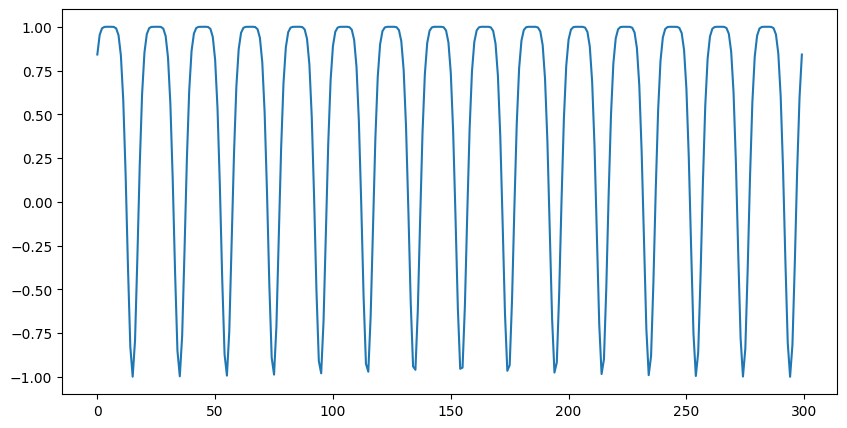

In [130]:
# sin(x + cos(x)) - periodic but not a plain sine, so the model has to learn a
# real waveform rather than a trivial one.
N = 300
x = torch.linspace(0,30*np.pi,N)

data = torch.sin(x + torch.cos(x))

plt.figure(figsize=(10,5))
plt.plot(data);

In [131]:
type(data)

torch.Tensor

In [132]:
# RNN + Linear head.
class RNN(nn.Module):
  def __init__(self,input_size, num_layer, hidden_size) -> None:
    super().__init__()

    self.rnn = nn.RNN(input_size,hidden_size,num_layer)

    self.out = nn.Linear(hidden_size,1)


  def forward(self,x):

   y,h = self.rnn(x)

   return self.out(y),h


In [133]:
# hidden_size=10, seqlen=30. A 30-step window is enough to cover a full cycle,
# which is what the model needs to infer where in the wave it is.
input_size = 1
num_layer = 1
hidden_size = 10
seqlen = 30

In [134]:
test_model = RNN(input_size,num_layer,hidden_size)
test_model

RNN(
  (rnn): RNN(1, 10)
  (out): Linear(in_features=10, out_features=1, bias=True)
)

In [135]:
# Shape check before training.
yhat, hh = test_model(torch.rand(size=(seqlen,1,input_size)))
yhat.shape, hh.shape

(torch.Size([30, 1, 1]), torch.Size([1, 1, 10]))

In [136]:
# The RNN's two outputs: y (every time step) and h (the final state only).
y, h = test_model.rnn(torch.rand(size=(seqlen,1,input_size)))
print(f'Shape of y (output for each sequence step before linear layer): {y.shape}')
print(f'Shape of h (final hidden state): {h.shape}')

Shape of y (output for each sequence step before linear layer): torch.Size([30, 1, 10])
Shape of h (final hidden state): torch.Size([1, 1, 10])


In [137]:
hh

tensor([[[-0.0121, -0.6867, -0.3485,  0.5843, -0.1185,  0.1185, -0.2162,
          -0.0319, -0.3508, -0.2270]]], grad_fn=<StackBackward0>)

In [138]:
# Weight shapes: weight_ih (10,1) and weight_hh (10,10).
for name, params in test_model.named_parameters():
  if 'weight' in name:
    print(f'{name} : {params.shape}')

rnn.weight_ih_l0 : torch.Size([10, 1])
rnn.weight_hh_l0 : torch.Size([10, 10])
out.weight : torch.Size([1, 10])


In [139]:
# Adam at lr=1e-4 with MSELoss. Regression on a continuous signal, so MSE is
# the right choice - unlike the alternating-sign notebook, the magnitudes here
# ARE predictable.
epochs = 50
model = RNN(input_size,num_layer,hidden_size)

lr = 1e-4
optimizer = torch.optim.Adam(model.parameters(),lr=lr)

criterion = nn.MSELoss()

In [140]:
criterion

MSELoss()

In [141]:
# Sliding-window training, same setup as the previous notebook.
# seqloss collects every window's loss and losses[epoch] is their mean - writing
# `seqloss = loss.item()` instead would record only the final window and give a
# needlessly noisy curve.
losses = []

for epoch in range(epochs):

  model.train()
  seqloss = []

  for seqi in range(N-seqlen):

    seq = data[seqi : seqi + seqlen].view(seqlen, 1,input_size)
    y = data[seqi + seqlen].view(1,1)

    yhat , hh = model(seq)

    loss = criterion(yhat[-1], y)
    seqloss.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


  losses.append(np.mean(seqloss))

  if epoch % 5 == 0 or epoch == epochs-1:
    print(f'Epoch : {epoch} | loss : {losses[epoch]}')

Epoch : 0 | loss : 0.11567777395248413
Epoch : 5 | loss : 0.06170041486620903
Epoch : 10 | loss : 0.0008122443687170744
Epoch : 15 | loss : 0.005203479900956154
Epoch : 20 | loss : 0.0013169461162760854
Epoch : 25 | loss : 1.6200483514694497e-05
Epoch : 30 | loss : 0.0012014424428343773
Epoch : 35 | loss : 0.0021641154307872057
Epoch : 40 | loss : 0.0021820315159857273
Epoch : 45 | loss : 0.0018302492098882794
Epoch : 49 | loss : 0.0014897274086251855


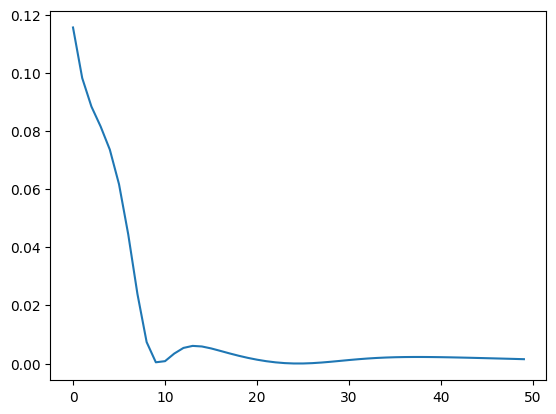

In [142]:
# Loss curve.
plt.plot(losses);

In [143]:
# ONE-STEP prediction across the training data: every window uses REAL past
# values. Errors cannot accumulate, because each prediction starts from ground
# truth.
yHat = np.zeros(N)
yHat[:] = np.nan


# loop over time segments
for timei in range(N-seqlen):

  # grab a snippet of data
  X = data[timei:timei+seqlen].view(seqlen,1,1)

  # forward pass and loss
  yy,hh = model(X)
  yHat[timei+seqlen] = yy[-1]

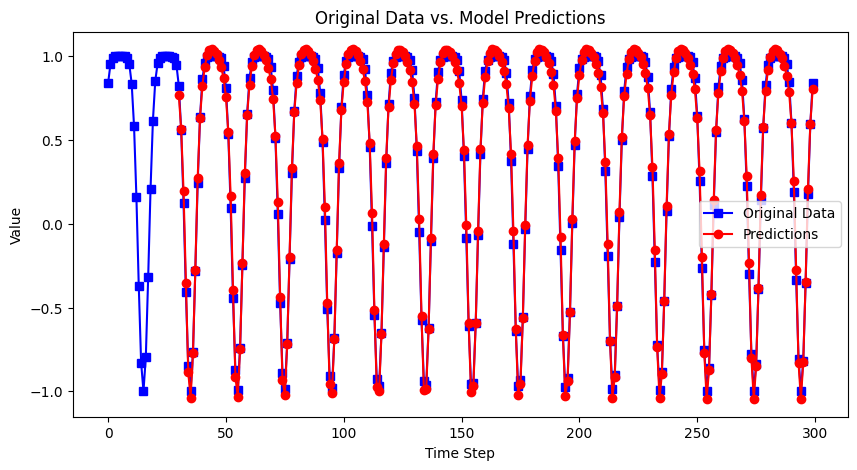

In [144]:
# Predictions over the true wave. This should look excellent - and it is the
# easy task.
plt.figure(figsize=(10,5))
plt.plot(data.detach().numpy(),'bs-', label='Original Data')
plt.plot(yHat,'ro-', label='Predictions')
plt.title('Original Data vs. Model Predictions')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()

Text(0.5, 1.0, 'r=1.00')

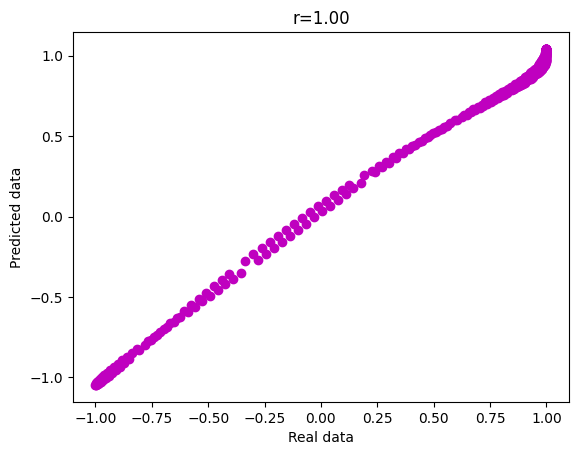

In [145]:
# Predicted vs actual with correlation. Near 1.0 for one-step prediction.
plt.plot(data[seqlen:],yHat[seqlen:],'mo')
plt.xlabel('Real data')
plt.ylabel('Predicted data')
r = np.corrcoef(data[seqlen:],yHat[seqlen:])
plt.title(f"r={r[0,1]:.2f}")

/tmp/ipykernel_7261/337957495.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff = data-yHat


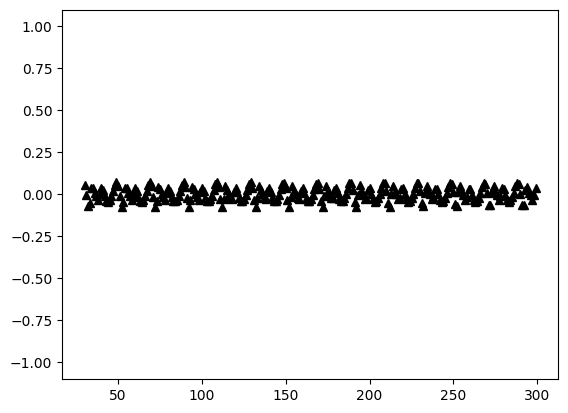

In [146]:
# Residuals - small and unstructured if the model fit well.
diff = data-yHat

plt.plot(diff,'k^')
plt.ylim([-1.1,1.1]);

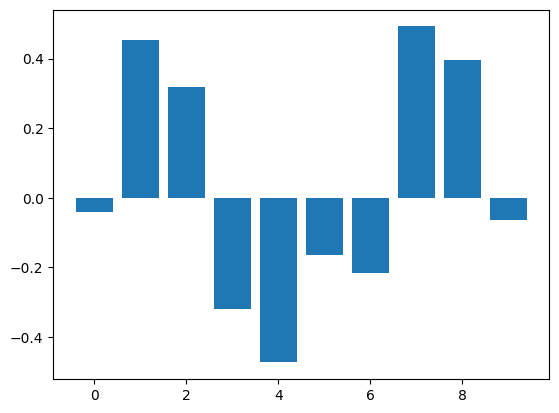

In [147]:
# The input-to-hidden weights, one bar per hidden unit: how strongly each unit
# responds to the incoming value.
plt.bar(range(hidden_size),model.rnn.weight_ih_l0.detach().squeeze());

#### Long term extrapolation

In [148]:
# FREE-RUNNING EXTRAPOLATION, the hard task.
# After the real data runs out, the model's own predictions become its input:
#   yHat[t+seqlen] = model(yHat[t : t+seqlen])
# Errors now COMPOUND - each small mistake becomes part of the next input, and
# the model was never trained on inputs that contain its own errors.
# That is exposure bias, and it is the central problem in sequence generation.
yHat = torch.zeros(2*N)
yHat[:N] = data.squeeze()

model.eval() # Set the model to evaluation mode for inference

# loop over time segments
for timei in range(2*N-seqlen):
  X = yHat[timei:timei+seqlen].view(seqlen,1,1)

  with torch.no_grad():
    yy,hh = model(X)

  yHat[timei+seqlen] = yy[-1].squeeze()

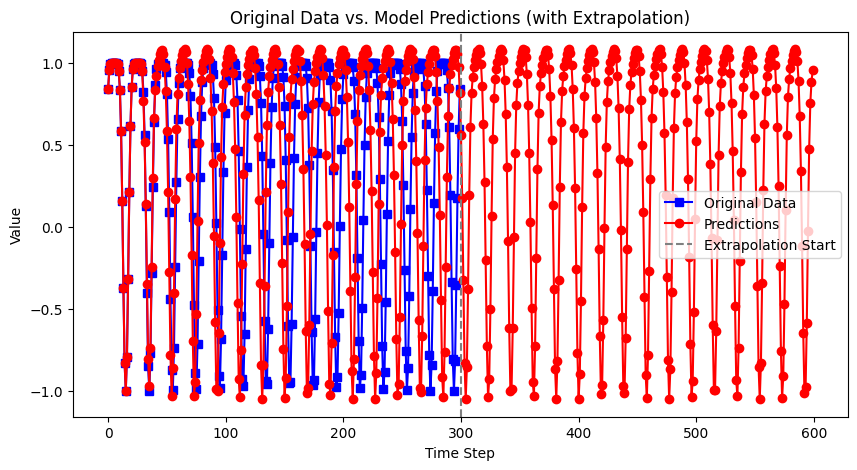

In [149]:
# The result. Left of the dashed line: real data. Right of it: pure generation.
# Expect the wave to decay - shrinking amplitude, drifting phase, often collapsing
# to a constant.
# Same lesson as ShiftedMNIST and the occlusion autoencoders: a model handles
# the inputs it was trained on. Teacher forcing and scheduled sampling exist to
# close exactly this gap.
plt.figure(figsize=(10,5))
plt.plot(data.detach().numpy(),'bs-', label='Original Data')
plt.plot(yHat.detach().numpy(),'ro-', label='Predictions')
plt.axvline(x=N, color='gray', linestyle='--', label='Extrapolation Start')
plt.title('Original Data vs. Model Predictions (with Extrapolation)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()